In [1]:
from IPython.display import HTML
HTML(open('../style.css').read())

# An Interpreter for a Simple Programming Language

In this notebook we develop an interpreter for a small programming language.

In [2]:
import ply.lex as lex

In [3]:
tokens = [ 'NUMBER',     # r'(0|[1-9][0-9]*)(\.[0-9]+)?([eE][+-]?[1-9][0-9]*)?'
           'STRING',     # r'("([^"]+|\\")*")'
           'IDENTIFIER', # r'[a-zA-Z][a-zA-Z0-9_]*'
           'ASSIGN',     # r':='
           'AND',        # r'&&'
           'OR',         # r'\|\|'
           'EQ',         # r'=='
           'NE',         # r'!='
           'LE',         # r'<='
           'GE',         # r'>='
           'IF',         # keyword, see below
           'WHILE',      # your code here
           'RETURN',
           'FOR',
           'FUNCTION'
          ]

We allow both *single-line comments* and *multi-line comments*.
- The regular expression `/\*(.|\n)*?\*/` recognizes multi-line comments.
  Multi-line comments start with the string `/*` and end with the string `*/`.
  Note the use of the *non-greedy* quantor `*?`.  If we have code like
  ```
  /* blah */ a := 1; /* blub */
  ```
  the greedy quantor would recognize the whole line as one comment. 
- The regular expression `//.*` recognizes single-line comments.
  A single line comment starts with the string `//` and extends to the end of the line.

In [4]:
def t_COMMENT(t):
    r'/\*(.|\n)*?\*/|//.*'
    t.lexer.lineno += t.value.count('\n')
    pass

The token `NUMBER` specifies a natural number.

In [5]:
def t_NUMBER(t):
    r'(0|[1-9][0-9]*)(\.[0-9]+)?([eE][+-]?[1-9][0-9]*)?'
    if '.' in t.value or 'e' in t.value or 'E' in t.value:
        t.value = float(t.value)
    else:
        t.value = int(t.value)
    return t

In [6]:
def t_STRING(t):
    r'("([^"]+|\\")*")'
    return t

In [7]:
t_ASSIGN = r':='
t_AND    = r'&&'
t_OR     = r'\|\|'
t_EQ     = r'=='
t_NE     = r'!='
t_LE     = r'<='
t_GE     = r'>='

The keywords 'if', 'while', 'return', etc. have to be dealt with separately as they are syntactical identical to identifiers. The dictionary Keywords shown below maps every keyword to its token type.

In [8]:
Keywords = { 'if': 'IF', 'while': 'WHILE' , 'return': 'RETURN', 'function': 'FUNCTION', 'for': 'FOR'} # your code here

When an identifier is read, we first have to check whether the identifier is one of our keywords.  If so, we assign the corresponding token type that is stored in the dictionary `Keywords`.  Otherwise, the token type is set to `IDENTIFIER`.

In [9]:
def t_IDENTIFIER(t):
    r'[a-zA-Z][a-zA-Z0-9_]*'
    t.type = Keywords.get(t.value, 'IDENTIFIER')
    return t

Operators consisting of a single character do not need an associated token type.
They are declared via the keyword `literals`.

In [10]:
literals = ['+', '-', '*', '/', '%', '(', ')', '{', '}', ';', '<', '>', ',', '!']

White space, i.e. *space characters*, *tabulators*, and *carriage returns* are ignored. 

In [11]:
t_ignore  = ' \t\r'

Syntactically, newline characters are ignored. However, we still need to keep track of them in order to know the current line number, which is used for error messages.

In [12]:
def t_newline(t):
    r'\n'
    t.lexer.lineno += 1
    return

Given a `token`, the function `find_colum` returns the column where `token` starts.  This is possible, because every token contains a reference to the current lexer as `token.lexer` and this lexer in turn stores the string that is given to it via the reference `lexer.lexdata`.  Furthermore, `token.lexpos` is the number of characters that precede `token`.

In [13]:
def find_column(token):
    program    = token.lexer.lexdata  # the complete string given to the scanner
    line_start = program.rfind('\n', 0, token.lexpos)
    return token.lexpos - line_start

The function `t_error` is called for any token `t` that can not be scanned by the lexer.  In this case, `t.value[0]` is the first character that is not recognized by the scanner.  This character is discarded.  After that, scanning proceeeds as if nothing has happened.

In [14]:
def t_error(t):
    column = find_column(t)
    print(f"Illegal character '{t.value[0]}' in line {t.lineno}, column {column}.")
    t.lexer.skip(1)

In [15]:
__file__ = 'main'

In [16]:
lexer = lex.lex()

In [17]:
def test_scanner(file_name):
    with open(file_name, 'r') as handle:
        program = handle.read() 
    print(program)
    lexer.input(program)
    lexer.lineno = 1          # reset line number
    for t in lexer:           # start scanning and collect all tokens
        print(t) 

In [18]:
test_scanner('Examples/sum-for.sl')

n := read();
function sum(n) {
    s := 0;
    for (i := 1; i <= n * n; i := i + 1) {
         s := s + i;
    }
    return s;
}
print("1 + 2 + ... + ", n, "*", n, " = ", sum(n));

LexToken(IDENTIFIER,'n',1,0)
LexToken(ASSIGN,':=',1,2)
LexToken(IDENTIFIER,'read',1,5)
LexToken((,'(',1,9)
LexToken(),')',1,10)
LexToken(;,';',1,11)
LexToken(FUNCTION,'function',2,13)
LexToken(IDENTIFIER,'sum',2,22)
LexToken((,'(',2,25)
LexToken(IDENTIFIER,'n',2,26)
LexToken(),')',2,27)
LexToken({,'{',2,29)
LexToken(IDENTIFIER,'s',3,35)
LexToken(ASSIGN,':=',3,37)
LexToken(NUMBER,0,3,40)
LexToken(;,';',3,41)
LexToken(FOR,'for',4,47)
LexToken((,'(',4,51)
LexToken(IDENTIFIER,'i',4,52)
LexToken(ASSIGN,':=',4,54)
LexToken(NUMBER,1,4,57)
LexToken(;,';',4,58)
LexToken(IDENTIFIER,'i',4,60)
LexToken(LE,'<=',4,62)
LexToken(IDENTIFIER,'n',4,65)
LexToken(*,'*',4,67)
LexToken(IDENTIFIER,'n',4,69)
LexToken(;,';',4,70)
LexToken(IDENTIFIER,'i',4,72)
LexToken(ASSIGN,':=',4,74)
LexToken(IDENTIFIER,'i',4,77)
LexToken(+,'+',4,7

In [19]:
import ply.yacc as yacc

Below is the grammar for our language:
```
program
    : 𝜆  
    | stmnt program
    ;
stmnt 
    : FUNCTION IDENTIFIER '(' id_list ')' stmnt              # new
    | IF '(' bool_expr ')' stmnt                 
    | WHILE '(' bool_expr ')' stmnt
    | FOR '(' assign ';' bool_expr ';' assign ')' stmnt      # new
    | '{' program '}' 
    | assign ';'                                             # new
    | expr ';'
    | RETURN expr ';'                                        # new
    ;
assign                                                       # new
    : IDENTIFIER ':=' expr 
    ;
id_list                                                      # new
    : 𝜆      
    | ne_id_list
    ;
ne_id_list                                                   # new
    : IDENTIFIER
    | IDENTIFIER ',' ne_id_list
    ;
bool_expr                                                     # new
    : bool_expr OR conjunction                                # new
    | conjunction
    ;
conjunction                                                   # new
    : conjunction AND negation                                # new
    | negation                                                # new
    ;
negation                                                      # new
    : '!' negation                                            # new
    | bool_atom                                               # new
    ; 
bool_atom
    : '(' bool_expr ')'                                       # new
    | expr '==' expr     
    | expr '!=' expr     
    | expr '<=' expr     
    | expr '>=' expr     
    | expr '<'  expr      
    | expr '>'  expr     
    ;
expr: expr '+' product                 
    | expr '-' product
    | product
    ;          
product
    : product '*' factor               
    | product '/' factor
    | factor
    ;
factor
    : '(' expr ')' 
    | NUMBER
    | IDENTIFIER
    | IDENTIFIER '(' expr_list ')'
    ;
expr_list
    : 𝜆 
    | ne_expr_list
    ;
ne_expr_list
    : expr
    | expr ',' ne_expr_list
    ;
```

The *start variable* of our grammar is `program`.

In [20]:
start = 'program'

An example program that conforms to this grammar is stored in the file `sum-for.sl` in the directory `Examples`.

In [21]:
!cat Examples/sum-for.sl

n := read();
function sum(n) {
    s := 0;
    for (i := 1; i <= n * n; i := i + 1) {
         s := s + i;
    }
    return s;
}
print("1 + 2 + ... + ", n, "*", n, " = ", sum(n));


A program is a list of statements.

In [22]:
def p_program_empty(p):
    "program : "
    p[0] = ('.',)

def p_program_more(p):
    "program : stmnt program"
    p[0] = ('.', p[1]) + p[2][1:]

In [23]:
def p_stmnt_function(p):
    "stmnt : FUNCTION IDENTIFIER '(' id_list ')' stmnt"
    p[0] = ('def', p[2], p[4], p[6])

def p_stmnt_if(p):
    "stmnt : IF '(' bool_expr ')' stmnt"
    p[0] = ('if', p[3], p[5])   

def p_stmnt_while(p):
    "stmnt : WHILE '(' bool_expr ')' stmnt"
    p[0] = ('while', p[3], p[5])

def p_stmnt_for(p):
    "stmnt : FOR '(' assign ';' bool_expr ';' assign ')' stmnt "
    # your code here
    p[0] = ('for', p[3], p[5], p[7], p[9])
    
def p_stmnt_block(p):
    "stmnt : '{' program '}'"
    p[0] = p[2]
    
def p_stmnt_assign(p):
    "stmnt : assign ';'"
    p[0] = p[1]

def p_stmnt_expr(p):
    "stmnt : expr ';'"
    p[0] = ('expr', p[1])

def p_stmnt_return(p):
    "stmnt : RETURN expr ';'"
    # your code here
    p[0] = ('return', p[2])

In [24]:
def p_assign(p):
    "assign : IDENTIFIER ASSIGN expr"
    p[0] = (':=', p[1], p[3])

In [25]:
def p_id_list_empty(p):
    "id_list : "
    p[0] = ('.',)
    
def p_id_list_ne(p):
    "id_list : ne_id_list"
    p[0] = p[1]     

def p_ne_id_list_one(p):
    "ne_id_list : IDENTIFIER"
    p[0] = ('.', p[1])

def p_ne_id_list_more(p):
    "ne_id_list : IDENTIFIER ',' ne_id_list"
    p[0] = ('.', p[1]) + p[3][1:]

In [26]:
def p_bool_expr_or(p):
    "bool_expr : bool_expr OR conjunction"
    # your code here
    p[0] = ('||', p[1], p[3])

def p_bool_expr_conj(p):
    "bool_expr : conjunction"
    # your code here
    p[0] = p[1]

In [27]:
def p_conjunction_and(p):
    "conjunction : conjunction AND negation"
    # your code here
    p[0] = ('&&', p[1], p[3])

def p_conjunction_neg(p):
    "conjunction : negation"
    # your code here
    p[0] = p[1]

In [28]:
def p_negation_not(p):
    "negation : '!' negation"
    # your code here
    p[0] = ('!', p[2])

def p_negation_atom(p):
     "negation : bool_atom"
     # your code here
     p[0] = p[1]

In [29]:
def p_bool_atom_paren(p):
    "bool_atom : '(' bool_expr ')'"
    # your code here
    p[0] = p[2]
    
def p_bool_atom_eq(p):
    "bool_atom : expr EQ expr"
    p[0] = ('==', p[1], p[3])

def p_bool_atom_ne(p):
    "bool_atom : expr NE expr"
    p[0] = ('!=', p[1], p[3])

def p_bool_atom_le(p):
    "bool_atom : expr LE expr"
    p[0] = ('<=', p[1], p[3])
    
def p_bool_atom_ge(p):
    "bool_atom : expr GE expr"
    p[0] = ('>=', p[1], p[3])
    
def p_bool_atom_lt(p):
    "bool_atom : expr '<' expr"
    p[0] = ('<', p[1], p[3])

def p_bool_atom_gt(p):
    "bool_atom : expr '>' expr"
    p[0] = ('>', p[1], p[3])

In [30]:
def p_expr_plus(p):
    "expr : expr '+' product"
    p[0] = ('+', p[1], p[3])
    
def p_expr_minus(p):
    "expr : expr '-' product"
    p[0] = ('-', p[1], p[3])

def p_expr_product(p):
    "expr : product"
    p[0] = p[1]
    
def p_product_times(p):
    "product : product '*' factor"
    p[0] = ('*', p[1], p[3])
    
def p_product_divide(p):
    "product : product '/' factor"
    p[0] = ('/', p[1], p[3])

def p_product_factor(p):
    "product : factor"
    p[0] = p[1]

def p_factor_paren(p):
    "factor : '(' expr ')'"
    p[0] = p[2]

def p_factor_number(p):
    "factor : NUMBER"
    p[0] = p[1]
    
def p_factor_string(p):
    "factor : STRING"
    p[0] = p[1]

def p_factor_identifier(p):
    "factor : IDENTIFIER"
    p[0] = p[1]

def p_factor_fct_call(p):
    "factor : IDENTIFIER '(' expr_list ')'"
    p[0] = ('call', p[1]) + p[3][1:]

In [31]:
def p_expr_list_empty(p):
    "expr_list : "
    p[0] = ('.',)
    
def p_expr_list_more(p):
    "expr_list : ne_expr_list"
    p[0] = p[1]

def p_ne_expr_list_one(p):
    "ne_expr_list : expr"
    p[0] = ('.', p[1]) 
    
def p_ne_expr_list_more(p):
    "ne_expr_list : expr ',' ne_expr_list"
    p[0] = ('.', p[1]) + p[3][1:] 

In [32]:
def p_error(t):
    column = find_column(t)
    if t:
        print(f'Syntax error at token "{t.value}" in line {t.lineno}, column {column}.')
    else:
        print('Syntax error at end of input.')

In [33]:
parser = yacc.yacc(write_tables=False, debug=True)

Generating LALR tables


The parser shown above will transform the program `sum.sl` into the *nested tuple* stored in the file `sum.ast`.

In [34]:
%run AST2Dot.ipynb

The function `parse` takes a `file_name` as ist sole argument.  The file is read and parsed. 
The resulting parse tree is visualized using `graphviz`.  It is important to reset the
attribute `lineno` of the scanner, for otherwise error messages will not have the correct line numbers.

In [35]:
def parse(file_name):
    lexer.lineno = 1
    with open(file_name, 'r') as handle:
        program = handle.read() 
    ast = yacc.parse(program)
    print(ast)
    return tuple2dot(ast)

In [36]:
!cat Examples/factorial.sl

function factorial(n) {
    if (n == 0) {
        return 1;
    }
    return n * factorial(n - 1);
}

for (i := 2; i <= 25; i := i + 1) {
    print(i, "! = ", factorial(i));
}


('.', ('def', 'factorial', ('.', 'n'), ('.', ('if', ('==', 'n', 0), ('.', ('return', 1))), ('return', ('*', 'n', ('call', 'factorial', ('-', 'n', 1)))))), ('for', (':=', 'i', 2), ('<=', 'i', 25), (':=', 'i', ('+', 'i', 1)), ('.', ('expr', ('call', 'print', 'i', '"! = "', ('call', 'factorial', 'i'))))))


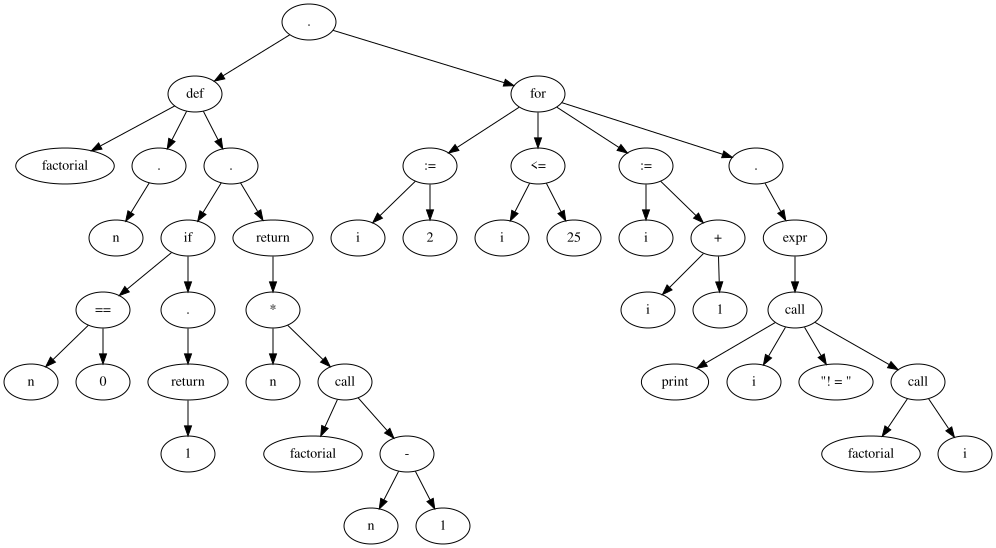

In [37]:
parse('Examples/factorial.sl')

In [38]:
from typing import TypeVar
NestedTuple = TypeVar('NestedTuple')
NestedTuple = int | str | tuple[NestedTuple, ...]
Number      = int | float

The class `ReturnValue` encapsulates a value that is to be returned.

In [39]:
class ReturnValue(Exception):
    def __init__(self, value):
        self.mValue = value

Below, we can see how we can catch an exception in Python.

In [40]:
try:
    raise ReturnValue(42)
except ReturnValue as result:
    print(result.mValue)

42


The type checker needs some forward declarations.

In [41]:
def execute(stmnt: NestedTuple, Values: dict[str, Number], Definitions: dict[str, NestedTuple]) -> None:
    return None # type: ignore

In [42]:
def evaluate(expr: NestedTuple, Values: dict[str, Number], Definitions: dict[str, NestedTuple]) -> Number:
    return None # type: ignore

The function `execute_tuple` takes three arguments:
- `Statement_List` is a list of statements,
- `Values` is a dictionary assigning floating point values to variable names.
- `Definitions` is a dictionary assigning function definitions to function names.
The function executes the statements in `Statement_List`.  If an assignment statement is executed, the dictionary `Values` is updated.

In [43]:
def execute_tuple(Statement_List: list[NestedTuple], 
                  Values: dict[str, Number], 
                  Definitions: dict[str, NestedTuple]) -> None:
    for stmnt in Statement_List:
        execute(stmnt, Values, Definitions)

The function `execute` takes three arguments:
- `stmnt` is a statement,
- `Values` is a dictionary assigning values to variable names.
- `Definitions` is a dictionary mapping function names to their definitions.
- 
The function executes the statements in `Statement_List`.  If an assignment statement is executed,
the dictionary `Values` is updated.

In [44]:
def execute(stmnt: NestedTuple, Values: dict[str, Number], Definitions: dict[str, NestedTuple]) -> None:
    match stmnt:
        case '.', *SL:
            execute_tuple(SL, Values, Definitions)
        case 'def', name, params, *SL: # function definions
             # your code here
             Definitions[name] = (params[1:], SL)
        case ':=', var, value:
            Values[var] = evaluate(value, Values, Definitions)
        case 'expr', expr:
            evaluate(expr, Values, Definitions)
        case 'if', test, *SL:
            if evaluate(test, Values, Definitions):
                execute_tuple(SL, Values, Definitions)
        case 'while', test, *SL:
            while evaluate(test, Values, Definitions):
                execute_tuple(SL, Values, Definitions)
        case 'for', init_assign, test, post_assign, *SL: # for statement
            # your code here
            # execute initial assignment
            execute(init_assign, Values, Definitions)
            # loop while the test expression is true
            while evaluate(test, Values, Definitions):
                execute_tuple(SL, Values, Definitions)
                # execute increment/step assignment after body
                execute(post_assign, Values, Definitions)
        case 'return', expr: # return statement
            # your code here, try to raise an exception
            raise ReturnValue(evaluate(expr, Values, Definitions))
        case 'call', _, *AL: # function calls are evaluated, not executed
            evaluate(stmnt, Values, Definitions)
        case _:
            assert False, f'{stmnt} unexpected'

In [45]:
import math

The function `evaluate` takes three arguments:
- `expr` is a logical expression or an arithmetic expression,
- `Values` is a dictionary assigning integer values to variable names.
- `Definitions` is a dictionary assigning function definitions to function names.
- 
The function evaluates the given expression and returns this value.

In [46]:
def evaluate(expr: NestedTuple, Values: dict[str, Number], Definitions: dict[str, NestedTuple]) -> Number:
    match expr:
        case int(number):
            return number
        case float(number):
            return number
        case str(name):
            if name[0] == '"' and name[-1] == '"':
                return name[1:-1] # type: ignore
            else:
                return Values[name] 
        case '||', lhs, rhs:
            return evaluate(lhs, Values, Definitions) or evaluate(rhs, Values, Definitions)
        case '&&', lhs, rhs:
            return evaluate(lhs, Values, Definitions) and evaluate(rhs, Values, Definitions)
        case '!', lhs:
            return not evaluate(lhs, Values, Definitions)
        case '==', lhs, rhs:
            return evaluate(lhs, Values, Definitions) == evaluate(rhs, Values, Definitions)
        case '!=', lhs, rhs:
            return evaluate(lhs, Values, Definitions) != evaluate(rhs, Values, Definitions)
        case '<', lhs, rhs:
            return evaluate(lhs, Values, Definitions) < evaluate(rhs, Values, Definitions)
        case '>', lhs, rhs:
            return evaluate(lhs, Values, Definitions) > evaluate(rhs, Values, Definitions)
        case '<=', lhs, rhs:
            return evaluate(lhs, Values, Definitions) <= evaluate(rhs, Values, Definitions)
        case '>=', lhs, rhs:
            return evaluate(lhs, Values, Definitions) >= evaluate(rhs, Values, Definitions)
        case '+', lhs, rhs:
            return evaluate(lhs, Values, Definitions) + evaluate(rhs, Values, Definitions)
        case '-', lhs, rhs:
            return evaluate(lhs, Values, Definitions) - evaluate(rhs, Values, Definitions)
        case '*', lhs, rhs:
            return evaluate(lhs, Values, Definitions) * evaluate(rhs, Values, Definitions)
        case '/', lhs, rhs:
            l = evaluate(lhs, Values, Definitions)
            r = evaluate(rhs, Values, Definitions) 
            if isinstance(l, float) or isinstance(r, float):
                return l / r
            else:
                return l // r
        case 'call', fct_name, *AL:
            if fct_name in Definitions:
                # your code here
                # lots of it!
                # remember that the function returns its value by raising an exception!

                params, body = Definitions[fct_name]
                NewValues = {}
                for i in range(len(params)):
                    NewValues[params[i]] = evaluate(AL[i], Values, Definitions)
                try:
                    execute_tuple(body, NewValues, Definitions)
                except ReturnValue as result:
                    return result.mValue
                
                # create a new local environment (shallow copy): function can read globals but changes stay local
                #local_values: dict[str, Number] = dict(Values)
                # evaluate arguments in caller environment and bind to parameters
                #for name, arg_expr in zip(param_names, AL):
                #    local_values[name] = evaluate(arg_expr, Values, Definitions)
                #try:
                #    execute(body, local_values, Definitions)
                #except ReturnValue as rv:
                #    return rv.mValue

            else:
                match fct_name:
                    case 'read':
                        s = input('Please enter a number: ')
                        if '.' in s or 'e' in s or 'E' in s:
                            return float(s)
                        else:
                            return int(s)
                    case 'print':
                        # print(evaluate(AL[0], Values, Definitions)) # your code here
                        # in case we have mor than one argument
                        # evaluate all arguments and print them space-separated
                        values = [evaluate(arg, Values, Definitions) for arg in AL]
                        print(*values)
                        
                    case 'sqrt':
                        return math.sqrt(evaluate(AL[0], Values, Definitions))
                    case 'exp':
                        return math.exp(evaluate(AL[0], Values, Definitions))
                    case 'ln':
                        return math.log(evaluate(AL[0], Values, Definitions))
                    case 'sin':
                        return math.sin(evaluate(AL[0], Values, Definitions))    
                    case 'cos':
                        return math.cos(evaluate(AL[0], Values, Definitions))    
                    case 'tan':
                        return math.tan(evaluate(AL[0], Values, Definitions))    
                    case 'arctan':
                        return math.atan(evaluate(AL[0], Values, Definitions))                        
                    case _:
                        assert False, f'function name {fct_name} is unknown'
        case _:
            assert False, f'{expr} unexpected' 
    return None # type: ignore

In [47]:
!cat Examples/factorial.sl

function factorial(n) {
    if (n == 0) {
        return 1;
    }
    return n * factorial(n - 1);
}

for (i := 2; i <= 25; i := i + 1) {
    print(i, "! = ", factorial(i));
}


In [48]:
def main(file):
    with open(file, 'r') as handle:
        program = handle.read()
    print(program)
    lexer.lineno = 1
    ast = yacc.parse(program)
    print(ast)
    display(tuple2dot(ast))
    Values = {}
    Definitions = {}
    execute(ast, Values, Definitions)

function factorial(n) {
    if (n == 0) {
        return 1;
    }
    return n * factorial(n - 1);
}

for (i := 2; i <= 25; i := i + 1) {
    print(i, "! = ", factorial(i));
}

('.', ('def', 'factorial', ('.', 'n'), ('.', ('if', ('==', 'n', 0), ('.', ('return', 1))), ('return', ('*', 'n', ('call', 'factorial', ('-', 'n', 1)))))), ('for', (':=', 'i', 2), ('<=', 'i', 25), (':=', 'i', ('+', 'i', 1)), ('.', ('expr', ('call', 'print', 'i', '"! = "', ('call', 'factorial', 'i'))))))


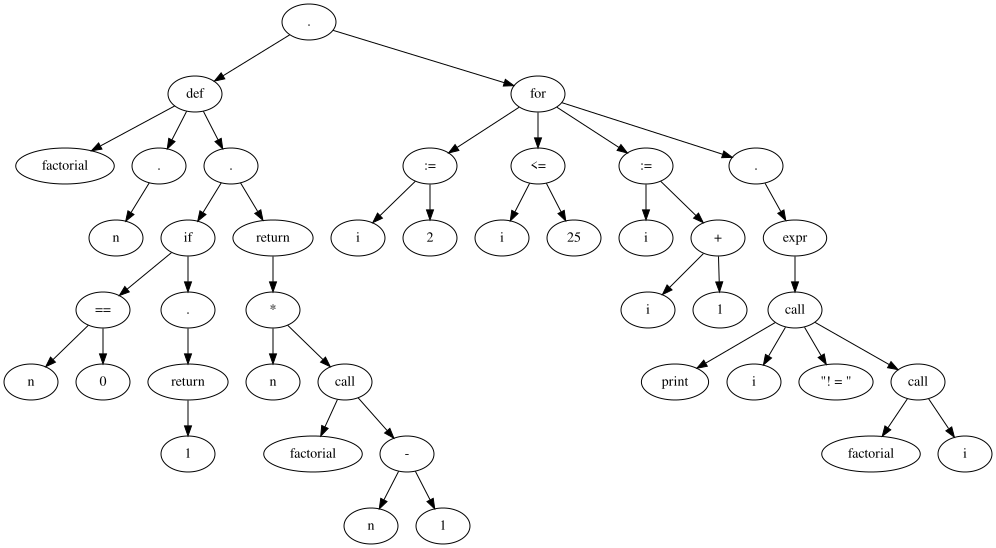

2 ! =  2
3 ! =  6
4 ! =  24
5 ! =  120
6 ! =  720
7 ! =  5040
8 ! =  40320
9 ! =  362880
10 ! =  3628800
11 ! =  39916800
12 ! =  479001600
13 ! =  6227020800
14 ! =  87178291200
15 ! =  1307674368000
16 ! =  20922789888000
17 ! =  355687428096000
18 ! =  6402373705728000
19 ! =  121645100408832000
20 ! =  2432902008176640000
21 ! =  51090942171709440000
22 ! =  1124000727777607680000
23 ! =  25852016738884976640000
24 ! =  620448401733239439360000
25 ! =  15511210043330985984000000


In [49]:
main('Examples/factorial.sl')



function abs(x) {
    if (x < 0) {
	return 0 - x;
    }
    return x;
}
print(abs(2-3));

// Solving the equation x = cos(x) iteratively.
function solve() {
    x    := 0;
    oldX := 1;
    while (abs(x - oldX) > 1.0e-15) {
        oldX := x;
        x := cos(x);
        print(x);
    }
    return x;
}

x := solve();
print(x);

// Recursive solution of the equation x = cos(x).
function solveRecursive(x) {
    if (abs(x - cos(x)) < 1.0e-15) {
        return x;
    }    
    return solveRecursive(cos(x));
}
x := solveRecursive(x);
print("The solution of the equation cos(x) = x is: ", x, ".");

('.', ('def', 'abs', ('.', 'x'), ('.', ('if', ('<', 'x', 0), ('.', ('return', ('-', 0, 'x')))), ('return', 'x'))), ('expr', ('call', 'print', ('call', 'abs', ('-', 2, 3)))), ('def', 'solve', ('.',), ('.', (':=', 'x', 0), (':=', 'oldX', 1), ('while', ('>', ('call', 'abs', ('-', 'x', 'oldX')), 1e-15), ('.', (':=', 'oldX', 'x'), (':=', 'x', ('call', 'cos', 'x')), ('expr', ('call', 'print', 'x')))),

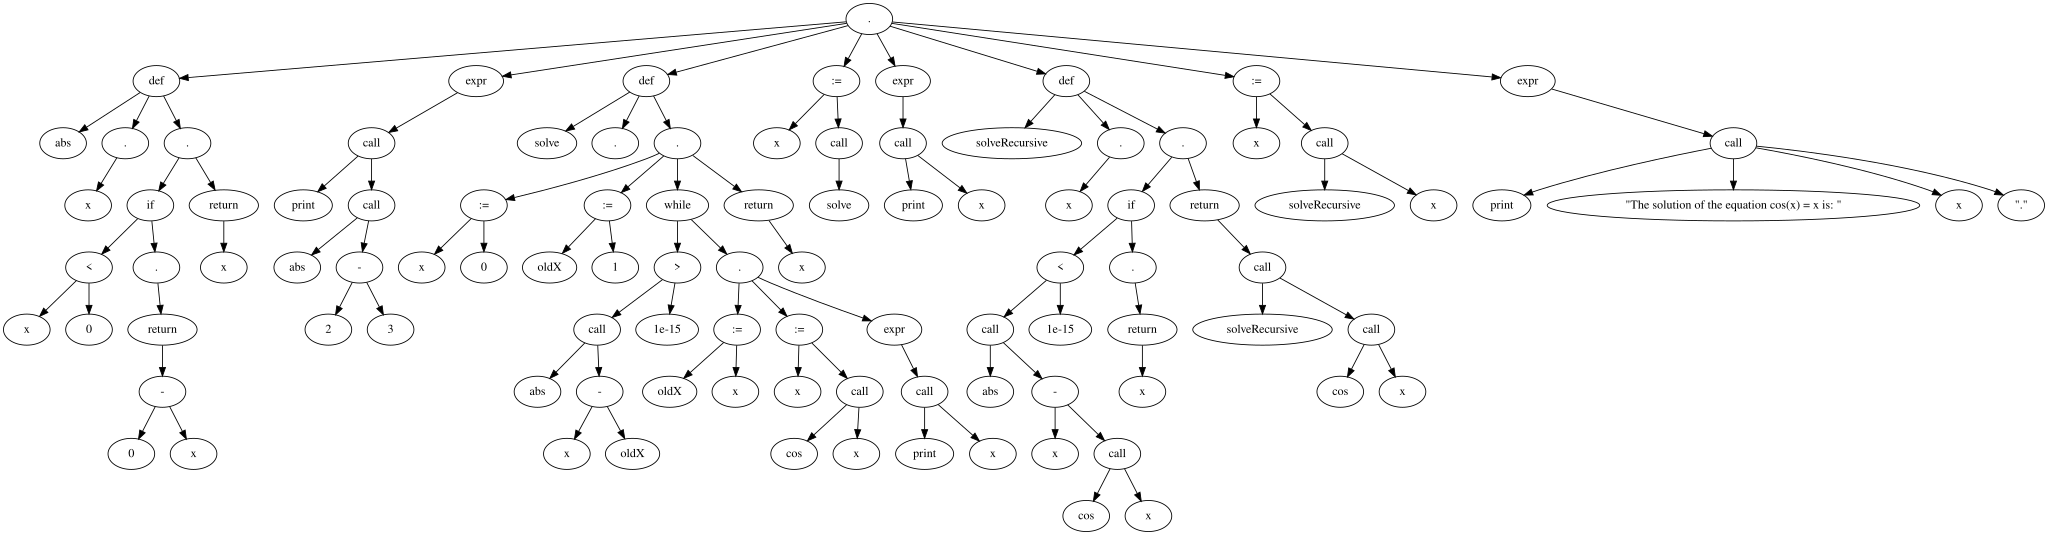

1
1.0
0.5403023058681398
0.8575532158463934
0.6542897904977791
0.7934803587425656
0.7013687736227565
0.7639596829006542
0.7221024250267077
0.7504177617637605
0.7314040424225098
0.7442373549005569
0.7356047404363474
0.7414250866101092
0.7375068905132428
0.7401473355678757
0.7383692041223232
0.7395672022122561
0.7387603198742113
0.7393038923969059
0.7389377567153445
0.7391843997714936
0.7390182624274122
0.7391301765296711
0.7390547907469174
0.7391055719265363
0.7390713652989449
0.7390944073790913
0.739078885994992
0.7390893414033927
0.7390822985224024
0.7390870426953322
0.7390838469650002
0.7390859996481299
0.7390845495752126
0.7390855263619245
0.7390848683867142
0.7390853116067619
0.7390850130484203
0.7390852141609171
0.739085078689123
0.7390851699445544
0.7390851084737987
0.7390851498812394
0.7390851219886894
0.7390851407774467
0.7390851281211138
0.7390851366465718
0.7390851309037207
0.7390851347721744
0.7390851321663374
0.7390851339216605
0.7390851327392538
0.7390851335357372
0.739085

In [50]:
main('Examples/solve.sl')

/* computing pi via a strange series */
function computePi(n) {
    pi := 0.0;
    f  := 1.0;
    for (k := 0; k <= n; k := k + 1) {
        k8 := 8.0 * k;
        pi := pi + (4.0 / (k8 + 1.0) - 2.0 / (k8 + 4.0) - 1.0 / (k8 + 5.0) - 1.0 / (k8 + 6.0)) / f;
        f := f * 16.0;
        print(pi);
    }
    return pi;
}

print("The number pi is: ", computePi(20));


('.', ('def', 'computePi', ('.', 'n'), ('.', (':=', 'pi', 0.0), (':=', 'f', 1.0), ('for', (':=', 'k', 0), ('<=', 'k', 'n'), (':=', 'k', ('+', 'k', 1)), ('.', (':=', 'k8', ('*', 8.0, 'k')), (':=', 'pi', ('+', 'pi', ('/', ('-', ('-', ('-', ('/', 4.0, ('+', 'k8', 1.0)), ('/', 2.0, ('+', 'k8', 4.0))), ('/', 1.0, ('+', 'k8', 5.0))), ('/', 1.0, ('+', 'k8', 6.0))), 'f'))), (':=', 'f', ('*', 'f', 16.0)), ('expr', ('call', 'print', 'pi')))), ('return', 'pi'))), ('expr', ('call', 'print', '"The number pi is: "', ('call', 'computePi', 20))))


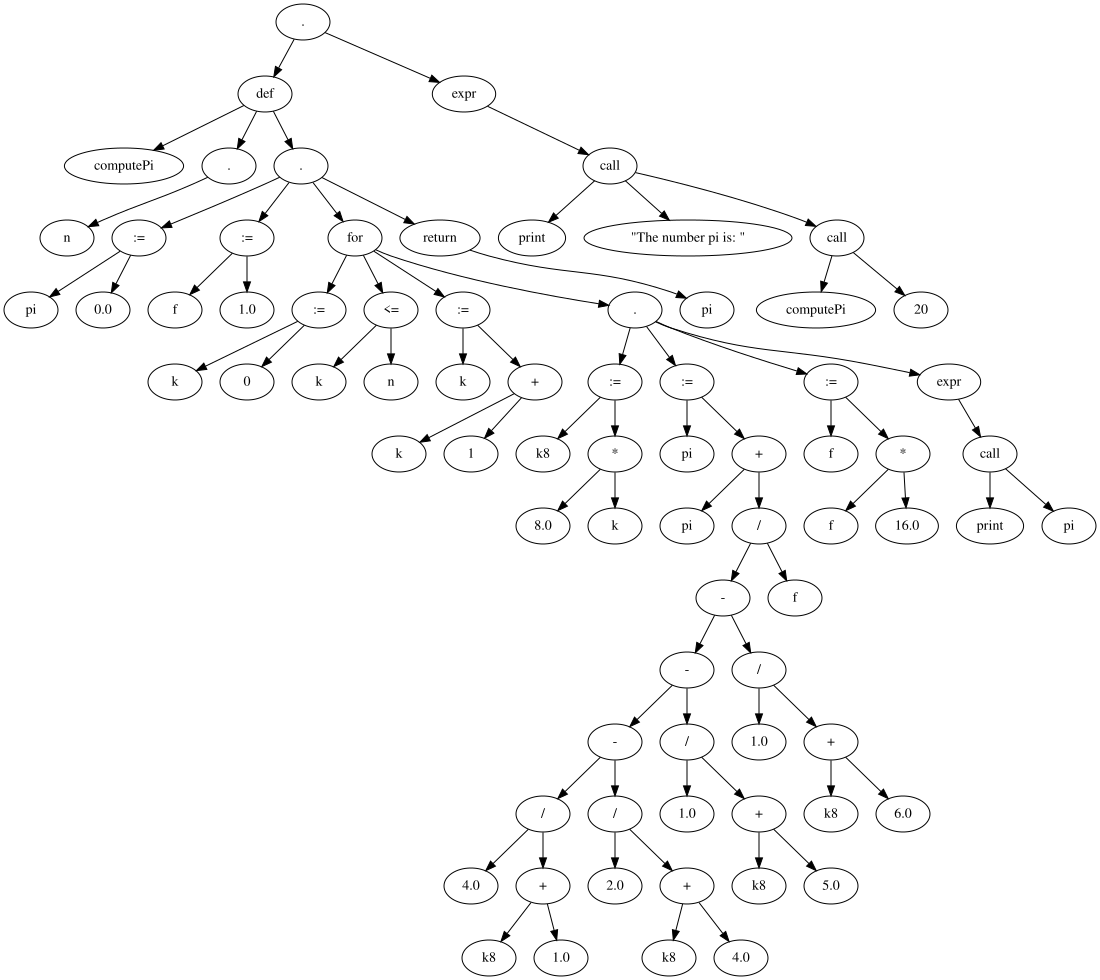

3.1333333333333333
3.1414224664224664
3.1415873903465816
3.1415924575674357
3.1415926454603365
3.141592653228088
3.141592653572881
3.141592653588973
3.1415926535897523
3.1415926535897913
3.141592653589793
3.141592653589793
3.141592653589793
3.141592653589793
3.141592653589793
3.141592653589793
3.141592653589793
3.141592653589793
3.141592653589793
3.141592653589793
3.141592653589793
The number pi is:  3.141592653589793


In [51]:
main('Examples/pi.sl')

n := read();
function sum(n) {
    s := 0;
    for (i := 1; i <= n * n; i := i + 1) {
         s := s + i;
    }
    return s;
}
print("1 + 2 + ... + ", n, "*", n, " = ", sum(n));

('.', (':=', 'n', ('call', 'read')), ('def', 'sum', ('.', 'n'), ('.', (':=', 's', 0), ('for', (':=', 'i', 1), ('<=', 'i', ('*', 'n', 'n')), (':=', 'i', ('+', 'i', 1)), ('.', (':=', 's', ('+', 's', 'i')))), ('return', 's'))), ('expr', ('call', 'print', '"1 + 2 + ... + "', 'n', '"*"', 'n', '" = "', ('call', 'sum', 'n'))))


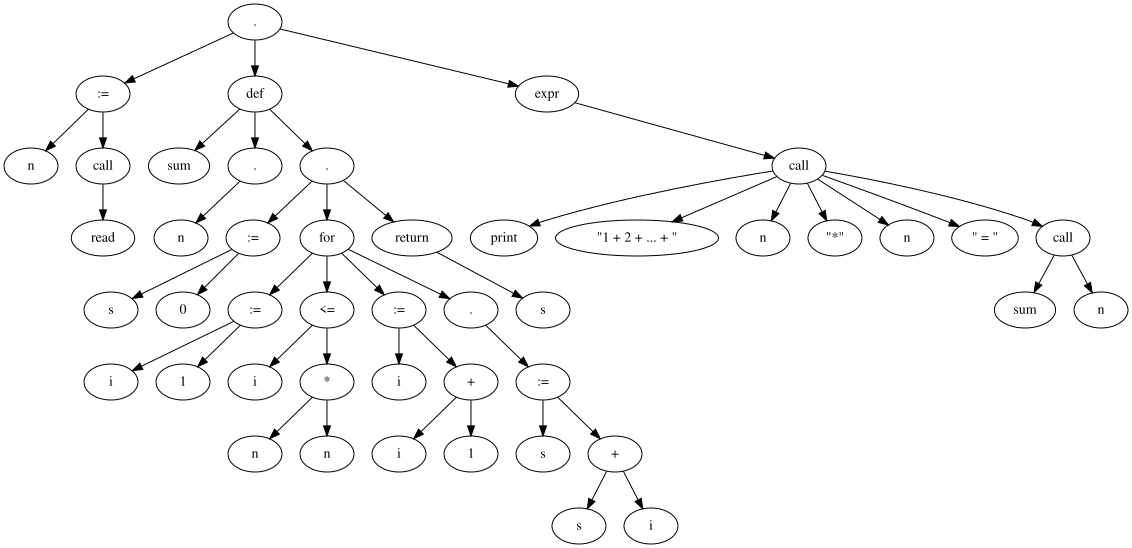

1 + 2 + ... +  7 * 7  =  1225


In [52]:
main('Examples/sum-for.sl')



function factorial(n) {
    if (n == 0) {
        return 1;
    }
    return n * factorial(n - 1);
}

function e(n) {
    sum := 1.0;
    for (i := 1; i <= n; i := i + 1) {
	sum := sum + 1.0 / factorial(i);
    }
    return sum;
}

print("Euler's number is: ", e(20));

('.', ('def', 'factorial', ('.', 'n'), ('.', ('if', ('==', 'n', 0), ('.', ('return', 1))), ('return', ('*', 'n', ('call', 'factorial', ('-', 'n', 1)))))), ('def', 'e', ('.', 'n'), ('.', (':=', 'sum', 1.0), ('for', (':=', 'i', 1), ('<=', 'i', 'n'), (':=', 'i', ('+', 'i', 1)), ('.', (':=', 'sum', ('+', 'sum', ('/', 1.0, ('call', 'factorial', 'i')))))), ('return', 'sum'))), ('expr', ('call', 'print', '"Euler\'s number is: "', ('call', 'e', 20))))


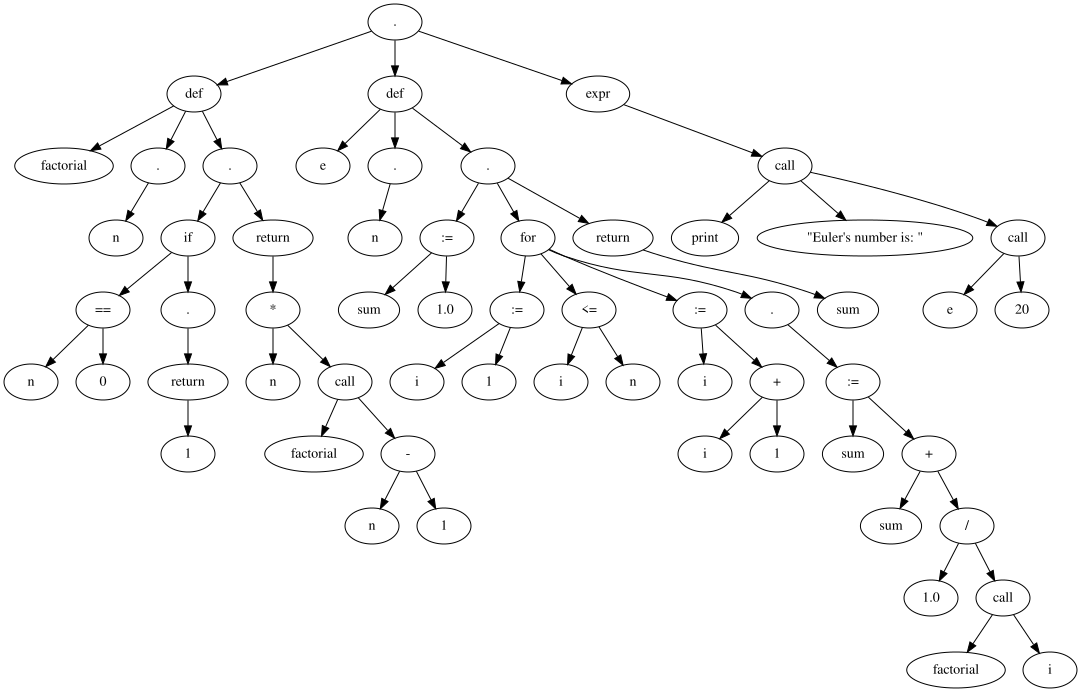

Euler's number is:  2.7182818284590455


In [53]:
main('Examples/e.sl')

In [54]:
math.exp(1)

2.718281828459045